**개념 정리**

규제가 있는 선형 모델: 릿지, 라쏘 엘라스틱넷

릿지 회귀
- 규제항을 비용 함수에 추가
    - 학습 알고리즘을 데이터에 맞추고 모델의 가중치를 작게 유지
    - 규제항은 훈련하는 동안에만 추가됨!
    - 훈련이 끝나면 성능을 규제가 없는 성능 지표로 평가
- 하이퍼파라미터 𝛼: 모델을 얼마나 규제할지 조절
    - 0이면 선형 회귀와 같아짐


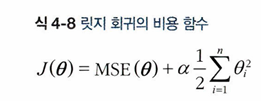

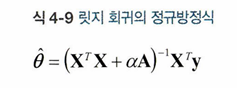

- l2 노름의 제곱을 2로 나눔

라쏘 회귀
- 가중치 벡터의 l1 노름을 사용

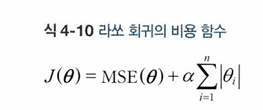

- 덜 중요한 특성의 가중치를 제거하려고 함
- 자동으로 특성 선택을 하고 희소 모델을 만듦
- 라쏘와 릿지의 차이
    - 릿지는 파라미터가 전역 최적점에 가까워질수록 그레이디언트가 작아짐
    - 릿지는 𝛼를 증가시킬수록 최적의 파라미터가 원점에 더 가까워지나 0이 되지는 X
- 𝛳=0일 때 서브그레이디언트 벡터를 사용하면 경사 하강법 적용 가능

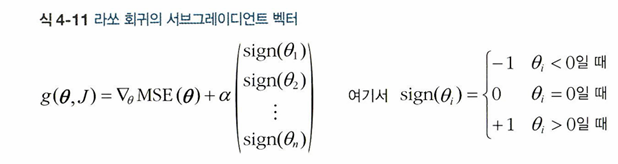

엘라스틱넷
- 릿지와 라쏘를 절충한 모델

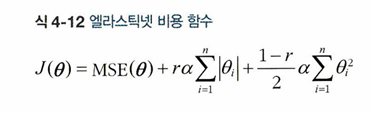

- r=0이면 릿지 회귀와 같고, r=1이면 라쏘 회귀와 같음

조기 종료
- 검증 에러가 최솟값에 도달하면 바로 훈련을 중지시키는 것

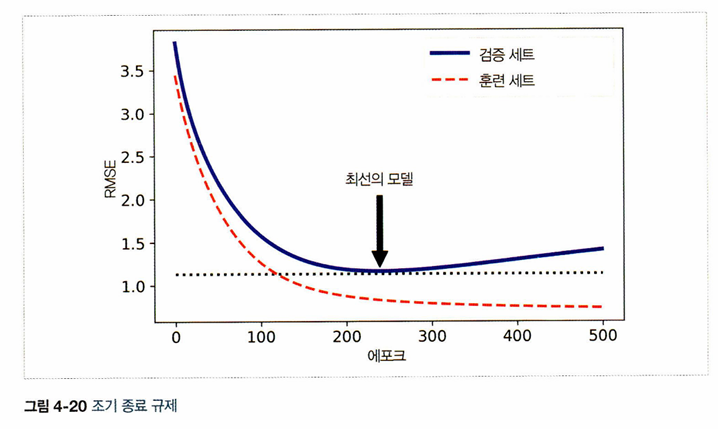

로지스틱 회귀
- 샘플이 특정 클래스에 속할 확률을 추정하는 데 널리 사용


확률 추정

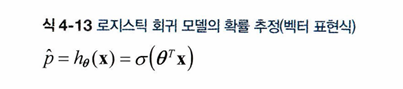

- 로지스틱은 0과 1사이의 값을 출력하는 시그모이드 함수

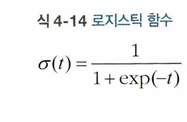

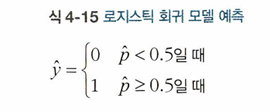

훈련과 비용 함수
- 양성 샘플에 대해서 높은 확률을 추정하고 음성 샘플에 대해서 낮은 확률을 추정


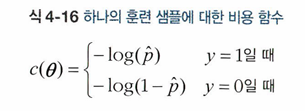

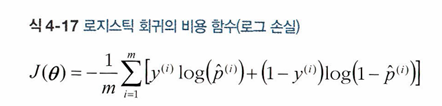

- 블록 함수이므로 경사 하강법이 전역 최솟값을 찾는 것을 보장

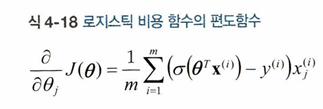

- 각 샘플에 대해 예측 오차를 계산하고 j번째 특성값을 곱해서 모든 훈련 샘플에 대해 평균을 냄
- 모든 편도 함수를 포함한 그레이디언트 벡터를 만들면 배치 경사 하강법 사용 가능

소프트맥스 회귀
- 로지스틱 회귀 모델을 여러 개의 이진 분류기를 훈련시켜 연결하지 않고 직접 다중 클래스를 지원하도록 일반화
- 샘플이 주어지면 먼저 소프트맥스 회귀 모델이 각 클래스 k에 대한 점수를 계산, 그 점수에 소프트맥스 함수 적용

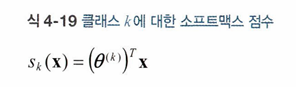

- 각 클래스는 자신만의 파라미터 벡터를 가짐, 이 벡터들은 파라미터 행렬에 행으로 저장

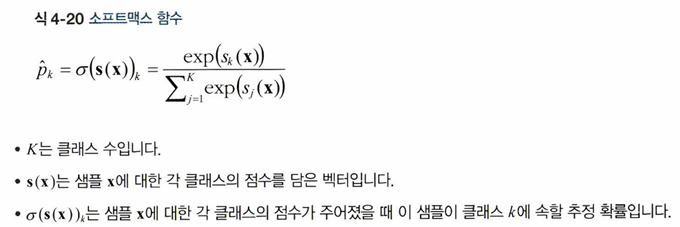

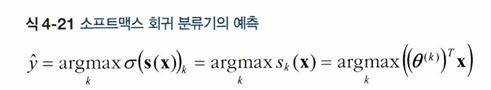

- argmax 연산은 함수를 최대화하는 변수의 값을 반환

- 모델이 타깃 클래스에 대해서 높은 확률을 추정하도록 만드는 것이 목표
    - 크로스 엔트로피 비용 함수를 최소화

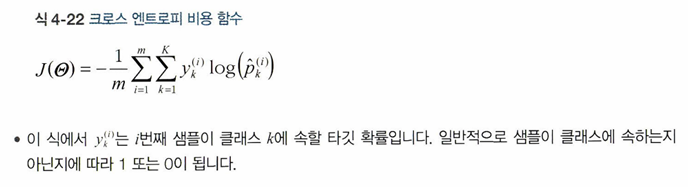

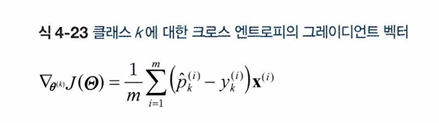

**코드 필사**

릿지

In [3]:
import numpy as np
m=100
X=6*np.random.rand(m,1)-3
y=0.5*X**2+X+2+np.random.randn(m,1)

In [4]:
from sklearn.linear_model import Ridge
ridge_reg=Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([4.77759835])

In [5]:
from sklearn.linear_model import SGDRegressor
sgd_reg=SGDRegressor(penalty="l2")
sgd_reg.fit(X,y.ravel())
sgd_reg.predict([[1.5]])

array([4.75779818])

라쏘

In [6]:
from sklearn.linear_model import Lasso
lasso_reg=Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([4.73162117])

엘라스틱넷

In [7]:
from sklearn.linear_model import ElasticNet
elastic_net=ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X,y)
elastic_net.predict([[1.5]])

array([4.73353206])

조기 종료

In [12]:
from sklearn.base import clone
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val=train_test_split(X, y, test_size=0.2)

#데이터 준비
poly_scaler=Pipeline([
    ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
    ("std_scaler", StandardScaler())
])
X_train_poly_scaled=poly_scaler.fit_transform(X_train)
X_val_poly_scaled=poly_scaler.transform(X_val)

sgd_reg=SGDRegressor(max_iter=1, tol=None, warm_start=True,
                     penalty=None, learning_rate="constant", eta0=0.0005)

minimum_val_error=float("inf")
best_epoch=None
best_model=None
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train.ravel()) #훈련을 이어서 진행
    y_val_predict=sgd_reg.predict(X_val_poly_scaled)
    val_error=mean_squared_error(y_val, y_val_predict)
    if val_error<minimum_val_error:
        minimum_val_error=val_error
        best_epoch=epoch
        best_model=clone(sgd_reg)

결정 경계

In [13]:
from sklearn import datasets
iris=datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [14]:
X=iris["data"][:, 3:] #꽃잎의 너비
y=(iris["target"]==2).astype(int) #1 Iris-Virginica면 1, 그렇지 않으면 0

In [15]:
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression()
log_reg.fit(X,y)

LogisticRegression()

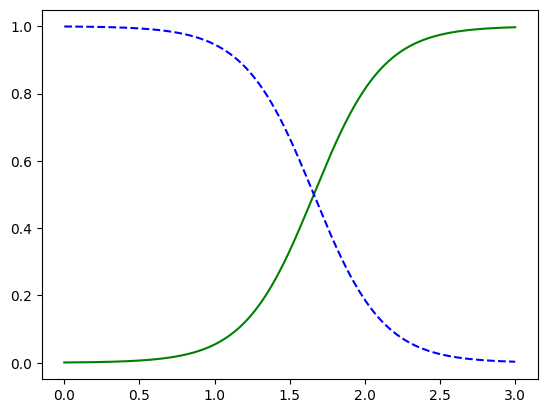

In [16]:
import matplotlib.pyplot as plt

X_new=np.linspace(0,3,1000).reshape(-1,1)
y_proba=log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:,1], "g-", label="Iris virginica")
plt.plot(X_new, y_proba[:,0], "b--", label="Not Iris virginica")

In [17]:
log_reg.predict([[1.7], [1.5]])

array([1, 0])

소프트맥스 회귀

In [18]:
X=iris["data"][:, (2,3)] #꽃잎 길이, 꽃잎 너비
y=iris["target"]

softmax_reg=LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10)
softmax_reg.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=10, multi_class='multinomial')

In [19]:
softmax_reg.predict([[5,2]])

array([2])

In [20]:
softmax_reg.predict_proba([[5,2]])

array([[6.21626374e-07, 5.73689802e-02, 9.42630398e-01]])